In [1]:
!pip install mlxtend -q

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

dataset = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter', 'Eggs'],
    ['Milk', 'Eggs'],
    ['Bread', 'Butter', 'Eggs'],
    ['Milk', 'Bread'],
    ['Milk', 'Bread', 'Eggs'],
    ['Bread', 'Butter', 'Milk'],
    ['Eggs', 'Butter'],
    ['Milk', 'Bread', 'Butter', 'Eggs'],
]

In [5]:
def get_support(itemset, dataset):
    count = sum(1 for t in dataset if set(itemset).issubset(set(t)))
    return count / len(dataset)

In [6]:
def get_frequent_itemsets(dataset, min_support):
    items = sorted(set(item for t in dataset for item in t))
    frequent = []
    k = 1
    candidates = [[i] for i in items]

    while candidates:
        frequent_k = [(c, get_support(c, dataset)) for c in candidates
                      if get_support(c, dataset) >= min_support]
        frequent.extend(frequent_k)
        k += 1
        candidates = [list(x) for x in combinations(items, k)
                      if all(list(s) in [f[0] for f in frequent_k]
                      for s in combinations(x, k-1))]
    return frequent

In [7]:
def generate_rules(frequent_itemsets, dataset, min_confidence):
    rules = []
    for itemset, support in frequent_itemsets:
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for ant in combinations(itemset, i):
                con = [x for x in itemset if x not in ant]
                confidence = get_support(itemset, dataset) / get_support(list(ant), dataset)
                lift = confidence / get_support(con, dataset)
                if confidence >= min_confidence:
                    rules.append((list(ant), con, round(support,2),
                                  round(confidence,2), round(lift,2)))
    return rules

In [1]:
def generate_rules(frequent_itemsets, dataset, min_confidence):
    rules = []
    for itemset, support in frequent_itemsets:
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for ant in combinations(itemset, i):
                con = [x for x in itemset if x not in ant]
                confidence = get_support(itemset, dataset) / get_support(list(ant), dataset)
                lift = confidence / get_support(con, dataset)
                if confidence >= min_confidence:
                    rules.append((list(ant), con, round(support,2),
                                  round(confidence,2), round(lift,2)))
    return rules

In [8]:
min_support    = 0.5
min_confidence = 0.6

frequent_itemsets = get_frequent_itemsets(dataset, min_support)
rules = generate_rules(frequent_itemsets, dataset, min_confidence)

print("Frequent Itemsets:")
for itemset, support in frequent_itemsets:
    print(f"  {itemset}  ->  support={support:.2f}")

print("\nAssociation Rules:")
print(f"  {'Antecedent':<25} {'Consequent':<15} {'Sup':>5} {'Conf':>6} {'Lift':>6}")
print("  " + "-"*60)
for ant, con, sup, conf, lift in rules:
    print(f"  {str(ant):<25} {str(con):<15} {sup:>5} {conf:>6} {lift:>6}")

Frequent Itemsets:
  ['Bread']  ->  support=0.80
  ['Butter']  ->  support=0.70
  ['Eggs']  ->  support=0.60
  ['Milk']  ->  support=0.70
  ['Bread', 'Butter']  ->  support=0.60
  ['Bread', 'Milk']  ->  support=0.60

Association Rules:
  Antecedent                Consequent        Sup   Conf   Lift
  ------------------------------------------------------------
  ['Bread']                 ['Butter']        0.6   0.75   1.07
  ['Butter']                ['Bread']         0.6   0.86   1.07
  ['Bread']                 ['Milk']          0.6   0.75   1.07
  ['Milk']                  ['Bread']         0.6   0.86   1.07


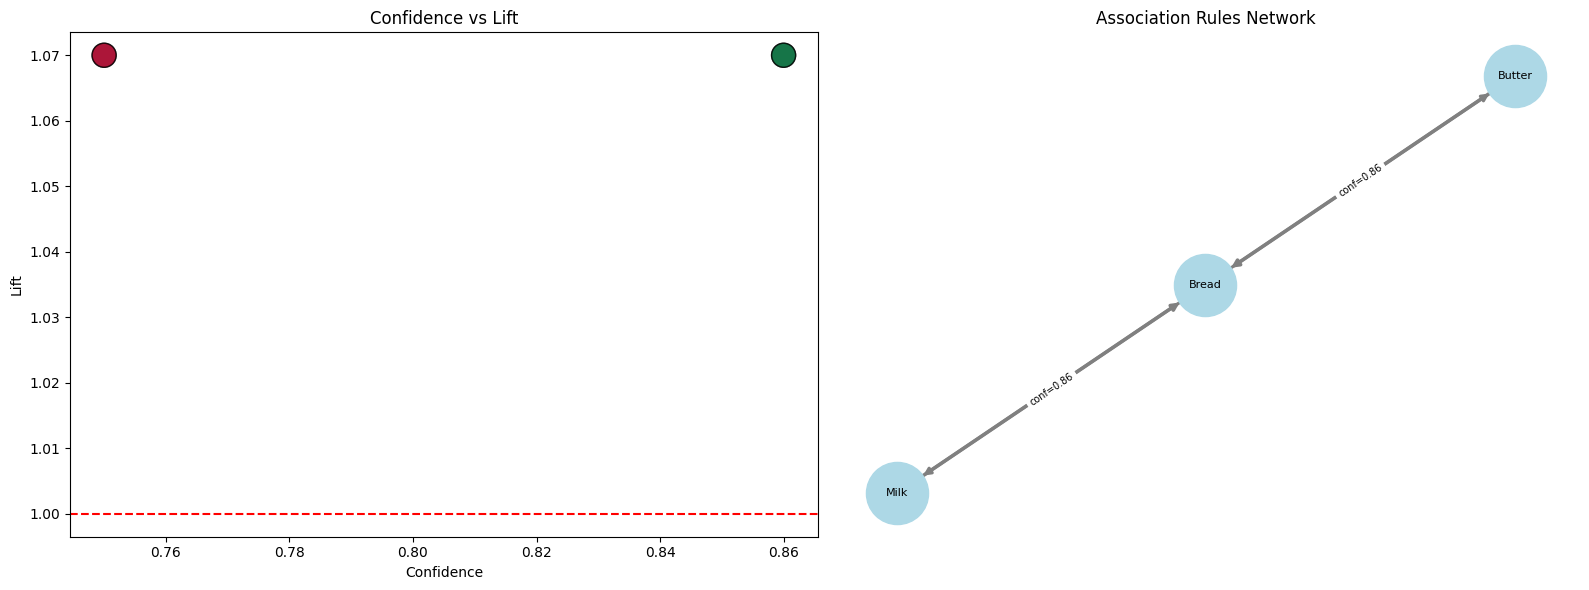

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
confs = [r[3] for r in rules]
lifts = [r[4] for r in rules]
sups  = [r[2] for r in rules]
axes[0].scatter(confs, lifts, s=[s*500 for s in sups], c=confs,
                cmap='RdYlGn', alpha=0.7, edgecolors='black')
axes[0].axhline(y=1, color='red', linestyle='--')
axes[0].set(xlabel='Confidence', ylabel='Lift', title='Confidence vs Lift')

# Network Graph
G = nx.DiGraph()
for ant, con, sup, conf, lift in rules:
    G.add_edge(', '.join(ant), ', '.join(con), weight=conf)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, ax=axes[1], node_size=2000,
        node_color='lightblue', font_size=8, arrows=True, edge_color='gray',
        width=[G[u][v]['weight']*3 for u,v in G.edges()])
nx.draw_networkx_edge_labels(G, pos, ax=axes[1], font_size=7,
        edge_labels={(u,v): f"conf={G[u][v]['weight']}" for u,v in G.edges()})
axes[1].set_title('Association Rules Network')

plt.tight_layout()
plt.show()